In [1]:
import matplotlib
import matplotlib.lines as lines
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
from PIL import Image

In [2]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

matplotlib.rc("font", size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc("axes", titlesize=MEDIUM_SIZE)     # fontsize of the axes title
matplotlib.rc("axes", labelsize=SMALL_SIZE)    # fontsize of the x and y labels
matplotlib.rc("xtick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("ytick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("legend", fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc("figure", titlesize=MEDIUM_SIZE)  # fontsize of the figure title

In [3]:
"""
H1 46.455278, -119.407778
L1 30.563056, -90.774444
V1 43.6313°N 10.5045°E
"""
h1 = (-90.774444, 30.563056)
l1 = (-119.407778, 46.455278)
v1 = (10.5045, 43.6313)

In [4]:
h1_img = np.asarray(Image.open("LIGO_H1_v3.jpg"))
h1_ratio = h1_img.shape[1]/h1_img.shape[0]
l1_img = np.asarray(Image.open("LIGO_L1_v2.jpg"))
l1_ratio = l1_img.shape[1]/l1_img.shape[0]
v1_img = np.asarray(Image.open("VIRGO_v1.jpg"))
v1_ratio = v1_img.shape[1]/v1_img.shape[0]

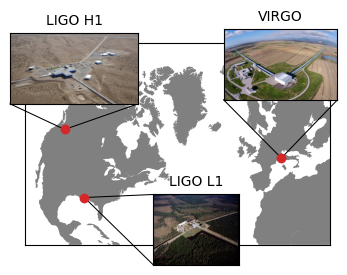

In [32]:
w, h = 10/2.54, 8/2.54
fig_ratio = w/h
fig, ax = plt.subplots(figsize=(w, h))
map = Basemap(projection="lcc", 
              lat_0=40, lon_0=-45,
              llcrnrlat=5 ,urcrnrlat=51,
              llcrnrlon=-100,urcrnrlon=82,
              resolution="l", area_thresh=10000, 
              ax=ax)
# map.drawcountries()
# parallels = np.arange(0, 80, 20)
# map.drawparallels(parallels, lw=0.75)
# meridians = np.arange(10, 360, 30)
# map.drawmeridians(meridians, lw=0.75)
map.fillcontinents(color="gray")
x, y = map(*(np.array([l1, h1, v1]).T))
ax.scatter(x, y, color="tab:red", zorder=10)
# ax.set_axis_off()

h1_ax = ax.inset_axes([-0.05, 0.7, h1_ratio/fig_ratio*0.35, 0.35])
h1_ax.imshow(h1_img, aspect="auto")
h1_ax.set_title("LIGO H1")
h1_ax.set_xticks([])
h1_ax.set_yticks([])

l1_ax = ax.inset_axes([0.42, -0.1, l1_ratio/fig_ratio*0.35, 0.35])
l1_ax.imshow(l1_img, aspect="auto")
l1_ax.set_title("LIGO L1")
l1_ax.set_xticks([])
l1_ax.set_yticks([])

v1_ax = ax.inset_axes([0.65, 0.72, v1_ratio/fig_ratio*0.35, 0.35])
v1_ax.imshow(v1_img, aspect="auto")
v1_ax.set_title("VIRGO")
v1_ax.set_xticks([])
v1_ax.set_yticks([])

def get_x0(ax): return ax.get_position().get_points()[0,0]
def get_x1(ax): return ax.get_position().get_points()[1,0]
def get_y0(ax): return ax.get_position().get_points()[0,1]
def get_y1(ax): return ax.get_position().get_points()[1,1]

def get_corner(ax, idx):
    points = ax.get_position().get_points()
    i = (idx[0], 0)
    j = (idx[1], 1)
    return (points[i], points[j])

def fig_to_ax(input):
    fig_to_display = fig.transFigure
    display_to_ax = ax.transData.inverted()
    return display_to_ax.transform(fig_to_display.transform(input))


xy = np.transpose([fig_to_ax(get_corner(h1_ax, (0,0))), [x[0], y[0]], fig_to_ax(get_corner(h1_ax, (1,0)))])
ax.plot(*xy, clip_on=False, c="k", lw=0.75, ls="-")

xy = np.transpose([fig_to_ax(get_corner(l1_ax, (0,1))), [x[1], y[1]], fig_to_ax(get_corner(l1_ax, (0,0)))])
ax.plot(*xy, clip_on=False, c="k", lw=0.75, ls="-")

xy = np.transpose([fig_to_ax(get_corner(v1_ax, (0,0))), [x[2], y[2]], fig_to_ax(get_corner(v1_ax, (1,0)))])
ax.plot(*xy, clip_on=False, c="k", lw=0.75, ls="-")
fig.savefig("LIGO_VIRGO.png", dpi=300, bbox_inches="tight")